# Worksheet 5 - Bayesian regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler

**Open data (processed data from Exercise 4):**

In [2]:
Sample_A = pd.read_csv('Sample_A.csv')
print(Sample_A)

        pl_rade  pl_radeerr1  pl_radeerr2  pl_radelim     pl_masse  \
0     16.140960     0.336270    -0.336270         0.0  4417.837000   
1      1.947000     0.038000    -0.038000         0.0     8.590000   
2      1.875000     0.029000    -0.029000         0.0     7.990000   
3      2.173000     0.097000    -0.098000         0.0     8.370000   
4      2.080000     0.160000    -0.170000         0.0     7.810000   
...         ...          ...          ...         ...          ...   
2690  15.356304     0.336269    -0.336269         0.0   225.658169   
2691  11.130518     0.212971    -0.212971         0.0  6356.568140   
2692   2.060000     0.030000    -0.030000         0.0     4.520000   
2693   2.110000     0.050000    -0.050000         0.0     4.300000   
2694   2.042000     0.050000    -0.050000         0.0     4.820000   

      pl_masseerr1  pl_masseerr2  pl_masselim  st_mass  st_masserr1  \
0       349.613000   -349.613000          0.0    0.108     0.011000   
1         0.43000

## 1. Single Kernel Model

**Model $log_{10}(M) = f(log_{10}(R))$** 

In [3]:
x = np.log10(Sample_A['pl_rade'])
y = np.log10(Sample_A['pl_masse'])

mass_error = Sample_A['mass_error_mean']
mass_error_log = mass_error / (Sample_A['pl_masse'] * np.log(10))

X = x.to_numpy().reshape(-1, 1) # in scikit learn the inputs (x) are expected as 2D matrix, while target values are expected to be a 1D vector

**define the Kernel (using sklearn):**

for $\sigma_{f}^{2}$: use of ConstantKernel \
for RBF itself: use of RBF \
for noise: use K + diag($\sigma_{n}^{2}$)

In [ ]:
alpha = (mass_error_log**2).to_numpy() # internally sklearn then uses K + diag(alpha)

In [5]:
def get_kernel(sigma_f, length_scale):
    return ConstantKernel(sigma_f) * RBF(length_scale)

arrays to test different ℓ and $\sigma_{f}$:

In [6]:
length_scales = [0.2, 1.0, 2.0]
length_scale_fixed = 1.0

sigma_fs = [0.3, 1.0, 3.0]
sigma_f_fixed = 1.0

In [7]:
# generate test data for evaluation (smooth grid)
x_prediction = np.linspace(X.min(), X.max(), 500).reshape(-1,1)

**Gaussian process: (still using sklearn):**

train the Gaussian Process Model using the prepared data (Sample_A) and make the predictions:

**vary ℓ, keep $\sigma_{f}$ fixed:**

In [19]:
results_l = {}
GP_l = {}

for l in length_scales:

    kernel = get_kernel(sigma_f_fixed, l)
    GP = GaussianProcessRegressor(kernel=kernel, alpha=alpha, optimizer=None)
    GP.fit(X, y)

    y_mean, y_std = GP.predict(x_prediction, return_std=True)
    results_l[l] = (y_mean, y_std)
    GP_l[l] = GP

**vary $\sigma_{f}$, keep ℓ fixed:**

In [20]:
results_sigma = {}
GP_sigma = {}

for s in sigma_fs:

    kernel = get_kernel(s, length_scale_fixed)
    GP = GaussianProcessRegressor(kernel=kernel, alpha=alpha, optimizer=None)
    GP.fit(X, y)

    y_mean, y_std = GP.predict(x_prediction, return_std=True)
    results_sigma[s] = (y_mean, y_std)
    GP_sigma[s] = GP

**look at the results for the varying parameters:**

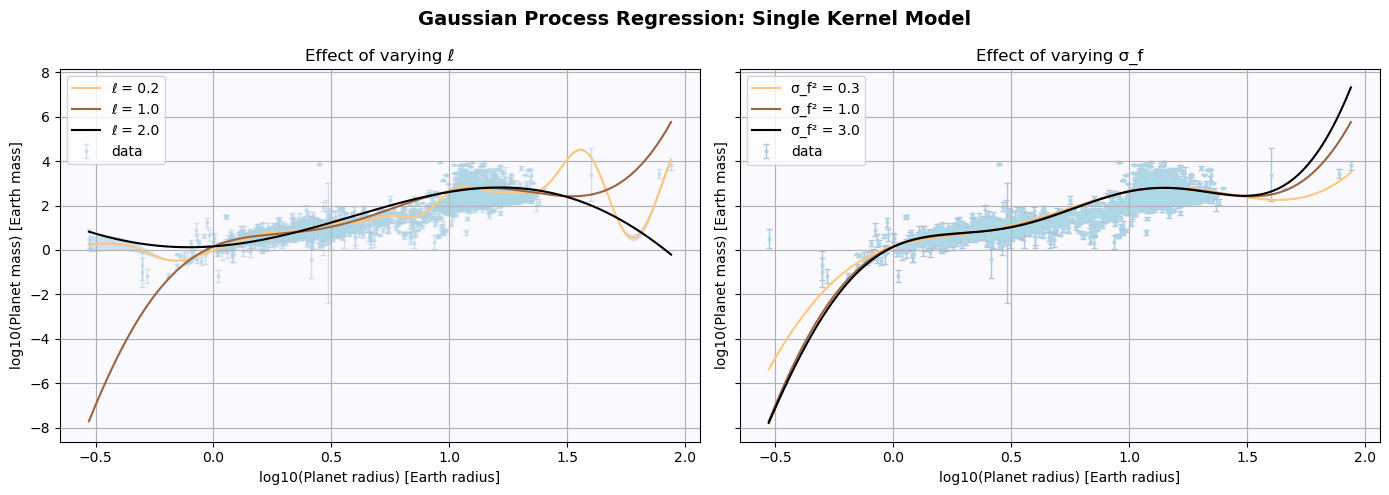

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

# varying scale length l
cmap = plt.colormaps['copper_r']
colors = cmap(np.linspace(0, 1, len(results_l)))

axes[0].errorbar(X, y, yerr=mass_error_log, fmt='o', markersize= 2, elinewidth=1, color='lightblue', ecolor='lightsteelblue', alpha=0.5, capsize=2, zorder=1, label='data')

for (l, (y_mean, y_std)), c in zip(results_l.items(), colors):
    axes[0].plot(x_prediction, y_mean, color=c, label=f'ℓ = {l}')

    axes[0].fill_between(x_prediction.flatten(), y_mean - y_std, y_mean + y_std, alpha=0.2)

axes[0].set_xlabel('log10(Planet radius) [Earth radius]')
axes[0].set_ylabel('log10(Planet mass) [Earth mass]')
axes[0].set_title('Effect of varying ℓ')
axes[0].grid()
axes[0].set_facecolor(color='lavender')
axes[0].patch.set_alpha(0.2)
axes[0].legend()

# varying sigma s:
cmap = plt.colormaps['copper_r']
colors = cmap(np.linspace(0, 1, len(results_sigma)))

axes[1].errorbar(X, y, yerr=mass_error_log, fmt='o', markersize= 2, elinewidth=1, color='lightblue', ecolor='lightsteelblue', capsize=2, zorder=1, label='data')

for (s, (y_mean, y_std)), c in zip(results_sigma.items(), colors):
    axes[1].plot(x_prediction, y_mean,color=c, label=f'σ_f² = {s}')

    axes[1].fill_between(x_prediction.flatten(), y_mean - y_std, y_mean + y_std, alpha=0.2)

axes[1].set_xlabel('log10(Planet radius) [Earth radius]')
axes[1].set_ylabel('log10(Planet mass) [Earth mass]')
axes[1].set_title('Effect of varying σ_f')
axes[1].grid()
axes[1].set_facecolor(color='lavender')
axes[1].patch.set_alpha(0.2)
axes[1].legend()

fig.suptitle('Gaussian Process Regression: Single Kernel Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Repeat with estimate for best fit parameters:

In [11]:
# Kernel:
kernel_new = ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(0.1) # noise is considered uniformly here!

# Gaussian process with optimizer:
GP_new = GaussianProcessRegressor(kernel=kernel_new, n_restarts_optimizer=10)

# Fit:
GP_new.fit(X,y)

GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.1),
                         n_restarts_optimizer=10)

In [12]:
# Estimated parameters

params = GP_new.kernel_.get_params()
#print(params)

sigma_f2 = params["k1__k1__constant_value"]
length_scale = params["k1__k2__length_scale"]
sigma_n2 = params["k2__noise_level"]

print(f'σ_f​²= {sigma_f2:.3f}')
print(f'ℓ= {length_scale:.3f}')
print(f'σₙ²= {sigma_n2:.3f}')

σ_f​²= 2.416
ℓ= 0.184
σₙ²= 0.130


In [13]:
#Predictions
y_mean_new, y_std_new = GP_new.predict(x_prediction, return_std=True)

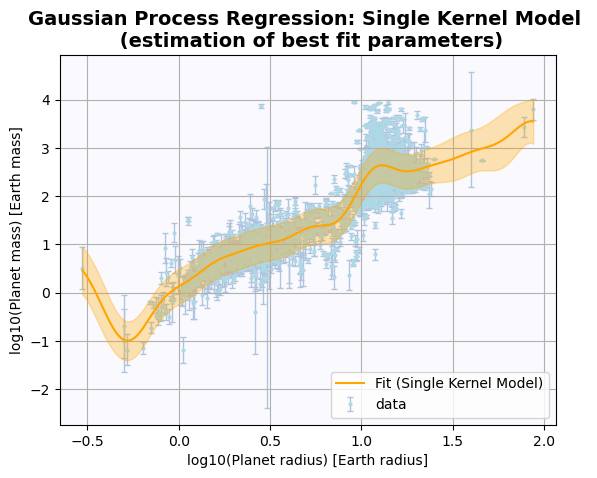

In [35]:
plt.errorbar(X, y, yerr=mass_error_log, fmt='o', markersize= 2, elinewidth=1, color='lightblue', ecolor='lightsteelblue', capsize=2, zorder=1, label='data')
plt.plot(x_prediction, y_mean_new, label='Fit (Single Kernel Model)', zorder=3, color='orange')
plt.fill_between(x_prediction.flatten(), y_mean_new - y_std_new, y_mean_new + y_std_new, alpha=0.3, zorder=2, color='orange')
plt.xlabel('log10(Planet radius) [Earth radius]')
plt.ylabel('log10(Planet mass) [Earth mass]')
plt.title('Gaussian Process Regression: Single Kernel Model \n (estimation of best fit parameters)', fontsize=14, fontweight='bold')
plt.grid()
plt.gca().set_facecolor(color='lavender')
plt.gca().patch.set_alpha(0.2)
plt.legend()
plt.legend()
plt.show()

**Test predictions for solar system planets:**

In [21]:
# Radii of the planets (taken from literature) in Earth units:

Mercury_radius = 0.382
Venus_radius = 0.949
Earth_radius = 1
Mars_radius = 0.532
Jupiter_radius = 11.209
Saturn_radius = 9.449
Uranus_radius = 4.007
Neptune_radius = 3.883

planet_names = ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune']

planets_radii = np.array([Mercury_radius, Venus_radius, Earth_radius, Mars_radius, Jupiter_radius, Saturn_radius, Uranus_radius, Neptune_radius])
planets_radii_log = np.log10(planets_radii)

X_planets = planets_radii_log.reshape(-1, 1)

In [24]:
# Prediction of solar system planets mass:

results_planets_l = {}

for l, model in GP_l.items():
    y_mean, y_std = model.predict(X_planets, return_std=True)
    results_planets_l[l] = (y_mean, y_std)

results_planets_sigma = {}

for s, model in GP_sigma.items():
    y_mean, y_std = model.predict(X_planets, return_std=True)
    results_planets_sigma[s] = (y_mean, y_std)

In [25]:
# true planets masses:

planet_masses_true = np.array([0.055, 0.815, 1.0, 0.107, 317.8, 95.2, 14.5, 17.1])

In [32]:
print('Predictions for solar system planets mass for varying ℓ')


for l in results_planets_l:
    y_mean, y_std = results_planets_l[l]
    print(f"\nℓ = {l}")

    for i in range(len(planet_names)):
        prediction = 10**y_mean[i]

        print(f'{planet_names[i]:8s} '
              f'True: {planet_masses_true[i]:.2f} | '
              f'Predicted: {prediction:.2f}')

Predictions for solar system planets mass for varying ℓ

ℓ = 0.2
Mercury  True: 0.06 | Predicted: 1.91
Venus    True: 0.81 | Predicted: 0.79
Earth    True: 1.00 | Predicted: 0.97
Mars     True: 0.11 | Predicted: 0.71
Jupiter  True: 317.80 | Predicted: 720.18
Saturn   True: 95.20 | Predicted: 246.35
Uranus   True: 14.50 | Predicted: 17.44
Neptune  True: 17.10 | Predicted: 16.93

ℓ = 1.0
Mercury  True: 0.06 | Predicted: 0.00
Venus    True: 0.81 | Predicted: 1.12
Earth    True: 1.00 | Predicted: 1.43
Mars     True: 0.11 | Predicted: 0.00
Jupiter  True: 317.80 | Predicted: 524.58
Saturn   True: 95.20 | Predicted: 378.38
Uranus   True: 14.50 | Predicted: 20.92
Neptune  True: 17.10 | Predicted: 18.99

ℓ = 2.0
Mercury  True: 0.06 | Predicted: 3.21
Venus    True: 0.81 | Predicted: 1.40
Earth    True: 1.00 | Predicted: 1.45
Mars     True: 0.11 | Predicted: 1.72
Jupiter  True: 317.80 | Predicted: 487.70
Saturn   True: 95.20 | Predicted: 366.28
Uranus   True: 14.50 | Predicted: 35.74
Neptune  Tru

In [ ]:
print('Predictions for solar system planets mass for varying σ_f')

for s in results_planets_sigma:
    y_mean, y_std = results_planets_sigma[s]
    print(f'\nσ_f = {s}')

    for i in range(len(planet_names)):
        prediction = 10**y_mean[i]

        print(f'{planet_names[i]:8s} '
              f'True: {planet_masses_true[i]:.2f} | '
              f'Predicted: {prediction:.2f}')

Predictions for solar system planets mass for varying σ_f 

σ_f = 0.3
Mercury  True: 0.06 | Predicted: 0.00
Venus    True: 0.81 | Predicted: 1.23
Earth    True: 1.00 | Predicted: 1.48
Mars     True: 0.11 | Predicted: 0.02
Jupiter  True: 317.80 | Predicted: 512.60
Saturn   True: 95.20 | Predicted: 372.23
Uranus   True: 14.50 | Predicted: 24.16
Neptune  True: 17.10 | Predicted: 21.93

σ_f = 1.0
Mercury  True: 0.06 | Predicted: 0.00
Venus    True: 0.81 | Predicted: 1.12
Earth    True: 1.00 | Predicted: 1.43
Mars     True: 0.11 | Predicted: 0.00
Jupiter  True: 317.80 | Predicted: 524.58
Saturn   True: 95.20 | Predicted: 378.38
Uranus   True: 14.50 | Predicted: 20.92
Neptune  True: 17.10 | Predicted: 18.99

σ_f = 3.0
Mercury  True: 0.06 | Predicted: 0.00
Venus    True: 0.81 | Predicted: 1.04
Earth    True: 1.00 | Predicted: 1.37
Mars     True: 0.11 | Predicted: 0.00
Jupiter  True: 317.80 | Predicted: 530.68
Saturn   True: 95.20 | Predicted: 378.86
Uranus   True: 14.50 | Predicted: 19.30
Nep

In [39]:
print('Predictions for solar system planets mass for best fit model')

y_mean_opt, y_std_opt = GP_new.predict(X_planets, return_std=True)
mass_planets_predicted = 10**y_mean_opt

for i in range(len(planet_names)):

    print(f'{planet_names[i]:8s} '
          f'True: {planet_masses_true[i]:8.2f} | '
          f'Predicted: {mass_planets_predicted[i]:8.2f} ')

Predictions for solar system planets mass for best fit model
Mercury  True:     0.06 | Predicted:     0.50 
Venus    True:     0.81 | Predicted:     1.18 
Earth    True:     1.00 | Predicted:     1.34 
Mars     True:     0.11 | Predicted:     0.10 
Jupiter  True:   317.80 | Predicted:   327.65 
Saturn   True:    95.20 | Predicted:   119.16 
Uranus   True:    14.50 | Predicted:    14.02 
Neptune  True:    17.10 | Predicted:    13.31 
